# Analyse du Risque de Crédit — Qualitative Bankruptcy Dataset

## Analyse Comparative Entre Les Modèles De Rating De Risque De Crédit
**Projet de Fin d'Année — Bank of Africa, Business Center Agadir**

---

### Dataset Description
This notebook analyzes the **Qualitative Bankruptcy** dataset from the UCI Machine Learning Repository.
Unlike other datasets in this study, **all features are purely qualitative** (ordinal: P=Positive, A=Average, N=Negative),
making this a unique case study for credit risk modeling with non-quantitative inputs.

- **Source**: UCI Machine Learning Repository
- **Records**: 250 firms
- **Features**: 6 qualitative factors (P/A/N)
- **Target**: Bankruptcy status (B=Bankrupt, NB=Not Bankrupt)
- **Problem Type**: Binary Classification

### Feature Description
| Feature | Description |
|---|---|
| Industrial Risk (IR) | Risk level of the industry the firm operates in |
| Management Risk (MR) | Quality and risk of the firm's management |
| Financial Flexibility (FF) | Ability of the firm to adapt to financial challenges |
| Credibility (CR) | Firm's credibility in the market |
| Competitiveness (CO) | Competitive position of the firm |
| Operating Risk (OR) | Risk associated with the firm's operations |

### Models Applied (4 Paradigms)
1. **Classical Econometric**: Logistic Regression, Probit (LDA & Z-Score N/A — explained)
2. **Machine Learning**: XGBoost, LightGBM, Random Forest, SVM, kNN, CART, MLP
3. **Structural & Market-Based**: Merton / KMV (N/A — explained)
4. **Dynamic Stochastic**: Markov Chains & Cox PH (N/A — explained)

This dataset ties directly to the **Heuristic / Judgemental** paradigm described in the research:
it represents how qualitative expert assessments can be used for credit scoring.

## Setup

In [1]:
import subprocess, sys
for pkg in ['lightgbm', 'shap']:
    try: __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

Installing lightgbm...
Installing shap...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import shap
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print('Libraries loaded.')

Libraries loaded.


---
## Phase 1 — Modeling Scope Framing

| Dimension | Description |
|---|---|
| **Scoring Type** | Acceptance Scoring — qualitative expert assessment of firms |
| **Population** | 250 firms assessed on 6 qualitative risk dimensions |
| **Time Horizon** | Cross-sectional (single snapshot) |
| **Data Structure** | All features are qualitative/ordinal (P=Positive, A=Average, N=Negative) |
| **Target** | Binary: Bankrupt (B) vs. Not Bankrupt (NB) |

This dataset represents the **Heuristic/Judgemental** approach to credit assessment, where human experts
assign qualitative ratings. The modeling exercise tests whether statistical and ML models can replicate
or improve upon such expert-based assessments.

---
## Phase 2 — Data Preparation and Cleansing

In [3]:
# Load data (no header in the original file)
col_names = ['Industrial_Risk', 'Management_Risk', 'Financial_Flexibility',
             'Credibility', 'Competitiveness', 'Operating_Risk', 'Class']

df = pd.read_csv('Qualitative_Bankruptcy.data.txt', header=None, names=col_names)
print(f'Dataset shape: {df.shape[0]} records, {df.shape[1]} attributes')
df.head(10)

Dataset shape: 250 records, 7 attributes


,Industrial_Risk,Management_Risk,Financial_Flexibility,Credibility,Competitiveness,Operating_Risk,Class
0,P,P,A,A,A,P,NB
1,N,N,A,A,A,N,NB
2,A,A,A,A,A,A,NB
3,P,P,P,P,P,P,NB
4,N,N,P,P,P,N,NB
5,A,A,P,P,P,A,NB
6,P,P,A,P,P,P,NB
7,P,P,P,A,A,P,NB
8,P,P,A,P,A,P,NB
9,P,P,A,A,P,P,NB


In [4]:
# Basic info
print('Data types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

# Target distribution
print(f'\nTarget distribution:')
print(df['Class'].value_counts())
print(f'Bankruptcy rate: {(df["Class"] == "B").mean():.2%}')

Data types:
Industrial_Risk          object
Management_Risk          object
Financial_Flexibility    object
Credibility              object
Competitiveness          object
Operating_Risk           object
Class                    object
dtype: object

Missing values: 0
Duplicates: 147

Target distribution:
Class
NB    143
B     107
Name: count, dtype: int64
Bankruptcy rate: 42.80%


In [5]:
# Encode ordinal features: N=0, A=1, P=2 (negative < average < positive)
ordinal_map = {'N': 0, 'A': 1, 'P': 2}
target_map = {'NB': 0, 'B': 1}

feature_cols = [c for c in df.columns if c != 'Class']
for col in feature_cols:
    df[col] = df[col].map(ordinal_map)

df['Class'] = df['Class'].map(target_map)
target_col = 'Class'

print('After encoding:')
df.head(10)

After encoding:


,Industrial_Risk,Management_Risk,Financial_Flexibility,Credibility,Competitiveness,Operating_Risk,Class
0,2,2,1,1,1,2,0
1,0,0,1,1,1,0,0
2,1,1,1,1,1,1,0
3,2,2,2,2,2,2,0
4,0,0,2,2,2,0,0
5,1,1,2,2,2,1,0
6,2,2,1,2,2,2,0
7,2,2,2,1,1,2,0
8,2,2,1,2,1,2,0
9,2,2,1,1,2,2,0


---
## Phase 3 — Sampling

In [6]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale for models that need it
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f'Training: {X_train.shape[0]} samples ({y_train.mean():.2%} bankruptcy rate)')
print(f'Test:     {X_test.shape[0]} samples ({y_test.mean():.2%} bankruptcy rate)')

Training: 175 samples (42.86% bankruptcy rate)
Test:     75 samples (42.67% bankruptcy rate)


---
## Phase 4 — Variable Analysis

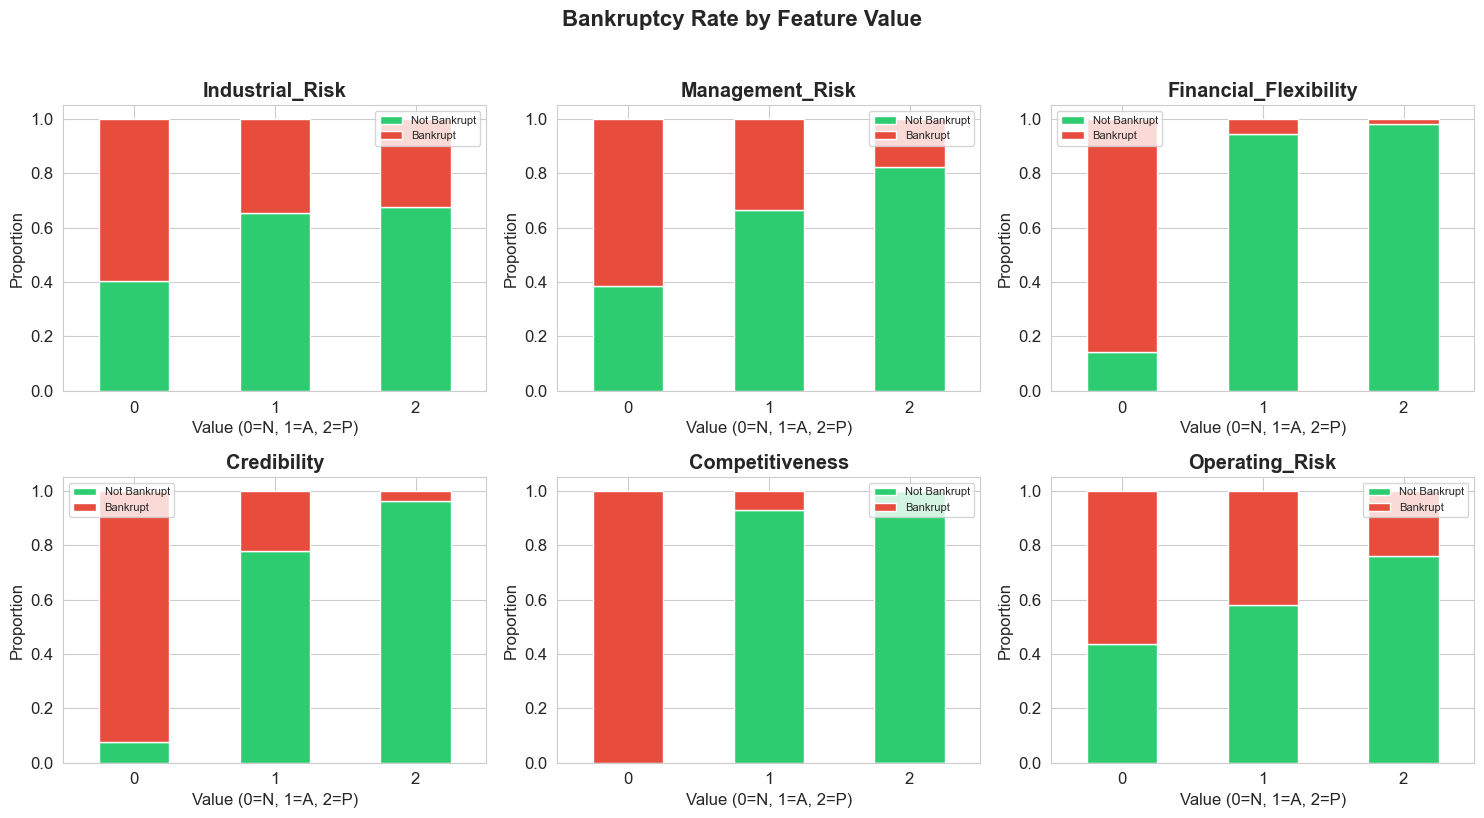

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    ct = pd.crosstab(df[col], df[target_col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value (0=N, 1=A, 2=P)')
    ax.set_ylabel('Proportion')
    ax.legend(['Not Bankrupt', 'Bankrupt'], fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('Bankruptcy Rate by Feature Value', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

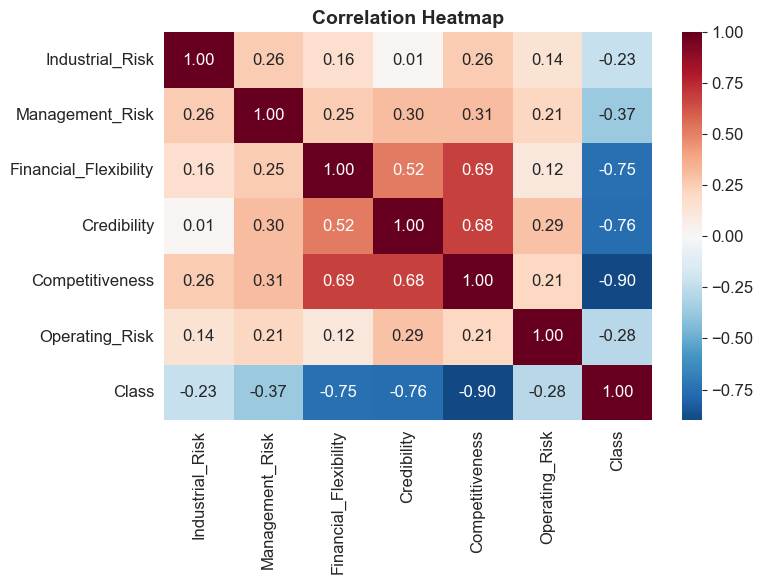

In [8]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 5 — Data Pre-processing

### WOE & Information Value

In [9]:
def calculate_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'events']
    grouped['non_events'] = grouped['total'] - grouped['events']
    te, tne = grouped['events'].sum(), grouped['non_events'].sum()
    grouped['er'] = grouped['events'].replace(0, 0.5) / te
    grouped['ner'] = grouped['non_events'].replace(0, 0.5) / tne
    grouped['woe'] = np.log(grouped['ner'] / grouped['er'])
    grouped['iv'] = (grouped['ner'] - grouped['er']) * grouped['woe']
    return grouped['iv'].sum()

iv_df = pd.DataFrame({
    'Feature': feature_cols,
    'IV': [calculate_iv(pd.concat([X_train, y_train], axis=1), c, target_col) for c in feature_cols]
}).sort_values('IV', ascending=False)

print('Information Value (IV):')
print(iv_df.to_string(index=False))

Information Value (IV):
              Feature       IV
      Competitiveness 8.690941
Financial_Flexibility 4.811152
          Credibility 3.832156
      Management_Risk 0.783747
      Industrial_Risk 0.291769
       Operating_Risk 0.262703


### VIF — Multicollinearity

> **Note**: VIF analysis is of limited value here because all features are ordinal with only 3 levels (0, 1, 2).
> Nevertheless, we compute it for completeness.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    'Feature': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)
print('VIF (>10 = severe multicollinearity):')
print(vif.to_string(index=False))

VIF (>10 = severe multicollinearity):
              Feature      VIF
      Competitiveness 5.920148
          Credibility 4.202423
Financial_Flexibility 4.124271
      Management_Risk 2.351960
      Industrial_Risk 2.302852
       Operating_Risk 2.186471


---
## Phase 6 — Modeling

In [11]:
results = {}
colors_plot = plt.cm.Set2(np.linspace(0, 1, 15))

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, paradigm='ML'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = 1 / (1 + np.exp(-model.decision_function(X_te)))
    else:
        y_prob = y_pred.astype(float)
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    gini = 2 * auc - 1
    f1 = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred)
    brier = brier_score_loss(y_te, y_prob)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ks = max(tpr - fpr)
    results[name] = {'paradigm': paradigm, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
                      'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,
                      'f1': f1, 'precision': prec, 'recall': rec, 'brier': brier}
    print(f'  {name}: Acc={acc:.4f}  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1={f1:.4f}  Brier={brier:.4f}')
    return model

### 6.1 Paradigm 1 — Classical Econometric / Statistical

In [12]:
print('=== Paradigm 1: Classical Econometric ===')
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

=== Paradigm 1: Classical Econometric ===
  Logistic Regression: Acc=0.9867  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=0.9846  Brier=0.0081


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [13]:
# Probit
X_tr_c = sm.add_constant(X_train_scaled)
X_te_c = sm.add_constant(X_test_scaled)
probit_res = sm.Probit(y_train, X_tr_c).fit(disp=0, maxiter=100)
yp_prob = probit_res.predict(X_te_c)
yp_pred = (yp_prob >= 0.5).astype(int)
acc = accuracy_score(y_test, yp_pred); auc = roc_auc_score(y_test, yp_prob)
gini = 2*auc-1; f1v = f1_score(y_test, yp_pred)
fpr_p, tpr_p, _ = roc_curve(y_test, yp_prob); ks = max(tpr_p - fpr_p)
brier = brier_score_loss(y_test, yp_prob)
results['Probit'] = {'paradigm': 'Econometric', 'model': probit_res, 'y_pred': yp_pred, 'y_prob': yp_prob,
                      'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,
                      'f1': f1v, 'precision': precision_score(y_test, yp_pred, zero_division=0),
                      'recall': recall_score(y_test, yp_pred), 'brier': brier}
print(f'  Probit: Acc={acc:.4f}  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1={f1v:.4f}  Brier={brier:.4f}')

  Probit: Acc=0.9867  AUC=0.9862  Gini=0.9724  KS=0.9688  F1=0.9841  Brier=0.0133


c:\Users\Elem\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Elem\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Elem\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Elem\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detect

#### Linear Discriminant Analysis (LDA)

> **APPLICABLE WITH CAVEATS**: LDA assumes that features follow a multivariate normal distribution
> with equal covariance matrices across classes. Our features are ordinal with only 3 values (0, 1, 2),
> which **severely violates the normality assumption**. We apply LDA nevertheless for comparison,
> but note that results should be interpreted with caution.

In [14]:
evaluate_model('LDA (caveats)', LinearDiscriminantAnalysis(),
               X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

  LDA (caveats): Acc=0.9867  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=0.9846  Brier=0.0110


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


#### Altman Z-Score

> **NOT APPLICABLE.**
> The Altman Z-Score formula Z = 0.012X₁ + 0.014X₂ + 0.033X₃ + 0.006X₄ + 0.999X₅ requires
> 5 specific **quantitative** financial ratios (Working Capital/TA, Retained Earnings/TA, EBIT/TA,
> Market Value Equity/Book Value Debt, Sales/TA).
>
> This dataset contains **only qualitative variables** rated on a 3-point ordinal scale (P/A/N).
> There are no quantitative financial ratios available to compute the Z-Score.
> This is a fundamental incompatibility: the Altman Z-Score is a quantitative model that cannot
> operate on qualitative inputs.

### 6.2 Paradigm 2 — Machine Learning

In [15]:
print('=== Paradigm 2: Machine Learning ===')
evaluate_model('XGBoost', xgb.XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss', verbosity=0), X_train, X_test, y_train, y_test, 'ML')
evaluate_model('LightGBM', lgb.LGBMClassifier(n_estimators=100, max_depth=4, is_unbalance=True, random_state=42, verbose=-1), X_train, X_test, y_train, y_test, 'ML')
evaluate_model('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test, 'ML')
evaluate_model('SVM', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test, 'ML')
evaluate_model('kNN', KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled, y_train, y_test, 'ML')
evaluate_model('CART', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test, 'ML')
evaluate_model('MLP', MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42, early_stopping=True), X_train_scaled, X_test_scaled, y_train, y_test, 'ML')

=== Paradigm 2: Machine Learning ===
  XGBoost: Acc=1.0000  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=1.0000  Brier=0.0028
  LightGBM: Acc=0.9867  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=0.9846  Brier=0.0124
  Random Forest: Acc=1.0000  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=1.0000  Brier=0.0036
  SVM: Acc=1.0000  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=1.0000  Brier=0.0021
  kNN: Acc=0.9867  AUC=1.0000  Gini=1.0000  KS=1.0000  F1=0.9846  Brier=0.0048
  CART: Acc=0.9867  AUC=0.9884  Gini=0.9767  KS=0.9767  F1=0.9846  Brier=0.0133
  MLP: Acc=0.9200  AUC=0.9913  Gini=0.9826  KS=0.9535  F1=0.9032  Brier=0.1524


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### 6.3 Paradigm 3 — Structural & Market-Based Models

> **NOT APPLICABLE.**
>
> The **Merton Option Pricing Model** treats firm equity as a European call option on firm assets.
> It requires: Market Value of Equity (E), Equity Volatility (σ_E), Book Value of Debt (D),
> Risk-Free Rate (r), and Debt Maturity (T).
>
> The **Moody's KMV Framework** extends Merton by mapping the Distance to Default to an
> Expected Default Frequency (EDF) using proprietary default databases.
>
> **Why inapplicable**: This dataset contains **exclusively qualitative variables** (P/A/N ordinal ratings).
> There is no quantitative financial data whatsoever — no balance sheet, no market data, no equity prices.
> Structural models are fundamentally designed for publicly traded companies with observable market prices.

### 6.4 Paradigm 4 — Dynamic Stochastic Models

> **NOT APPLICABLE.**
>
> **Markov Chains (Credit Migration)**: Require panel data where the same entities are observed
> across multiple time periods with transitions between credit states. This dataset is a single
> cross-sectional snapshot — each firm appears only once with no temporal dimension.
>
> **Cox Proportional Hazards (Survival Analysis)**: Requires a time-to-event variable
> (time from observation start to default or censoring). There is no time dimension in this dataset —
> no dates, no durations, no temporal ordering.
>
> **Both models are fundamentally impossible** without longitudinal/temporal data.

---
## Phase 7 — Evaluation on Test Set

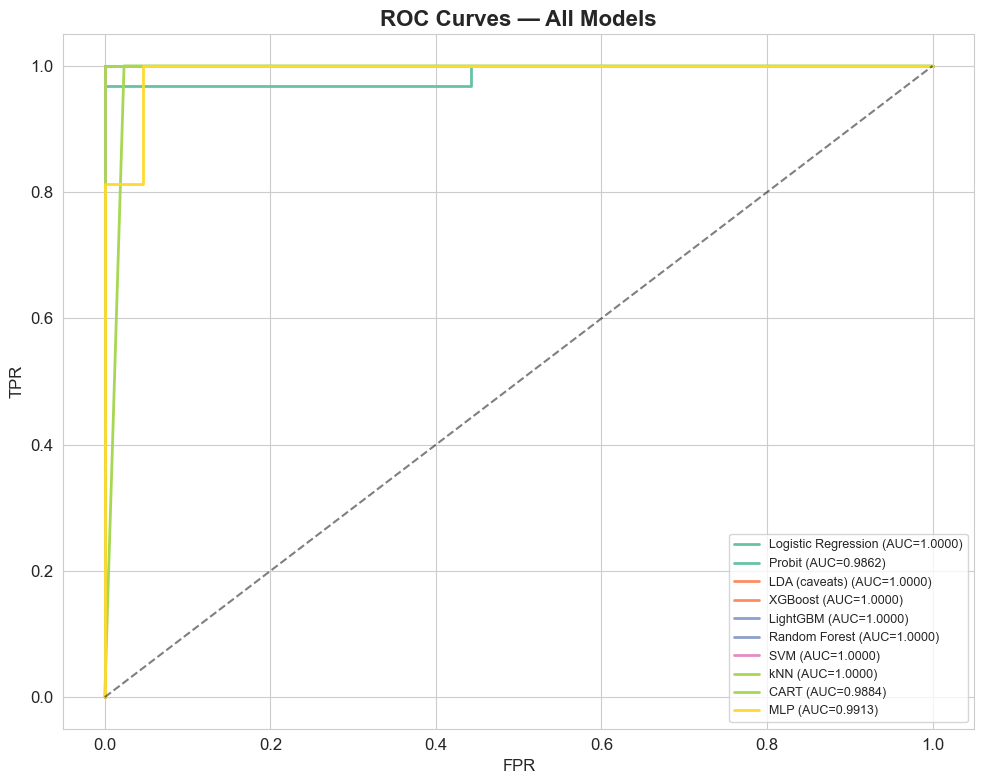

In [16]:
# ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", color=colors_plot[i], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

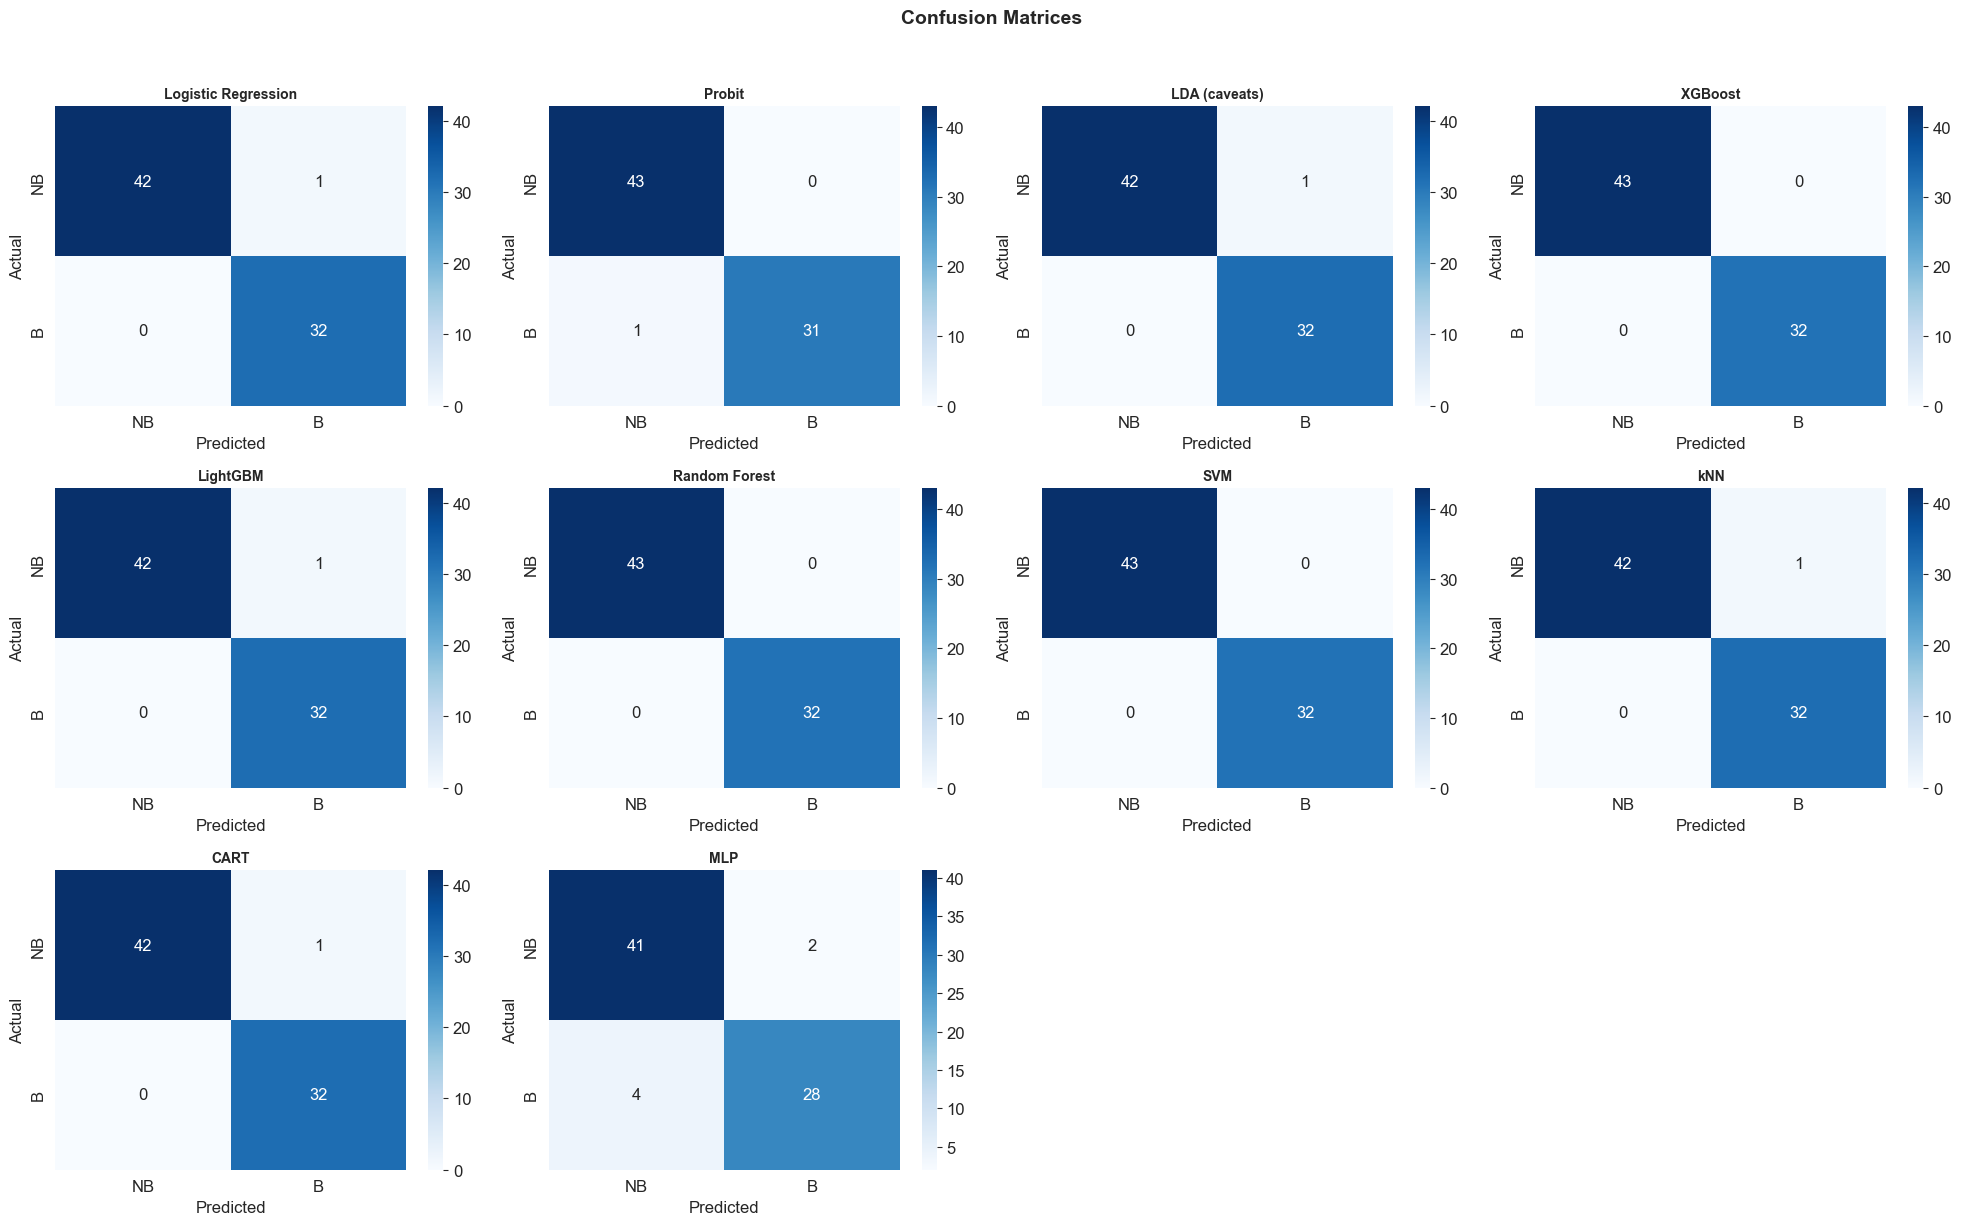

In [17]:
# Confusion matrices
n = len(results); nc = 4; nr = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['NB', 'B'], yticklabels=['NB', 'B'])
    axes[i].set_title(name, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [18]:
for name, res in results.items():
    print(f'\n=== {name} ({res["paradigm"]}) ===')
    print(classification_report(y_test, res['y_pred'], target_names=['Not Bankrupt', 'Bankrupt']))


=== Logistic Regression (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       1.00      0.98      0.99        43
    Bankrupt       0.97      1.00      0.98        32

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75


=== Probit (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       0.98      1.00      0.99        43
    Bankrupt       1.00      0.97      0.98        32

    accuracy                           0.99        75
   macro avg       0.99      0.98      0.99        75
weighted avg       0.99      0.99      0.99        75


=== LDA (caveats) (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       1.00      0.98      0.99        43
    Bankrupt       0.97      1.00      0.98        32

    accuracy                           0.99        75
   macro avg      

In [19]:
print('KS Statistic:')
for name, res in sorted(results.items(), key=lambda x: x[1]['ks'], reverse=True):
    print(f"  {name:25s}  KS = {res['ks']:.4f}")

KS Statistic:
  Logistic Regression        KS = 1.0000
  LDA (caveats)              KS = 1.0000
  XGBoost                    KS = 1.0000
  LightGBM                   KS = 1.0000
  Random Forest              KS = 1.0000
  SVM                        KS = 1.0000
  kNN                        KS = 1.0000
  CART                       KS = 0.9767
  Probit                     KS = 0.9688
  MLP                        KS = 0.9535


---
## Phase 8 — Model Calibration

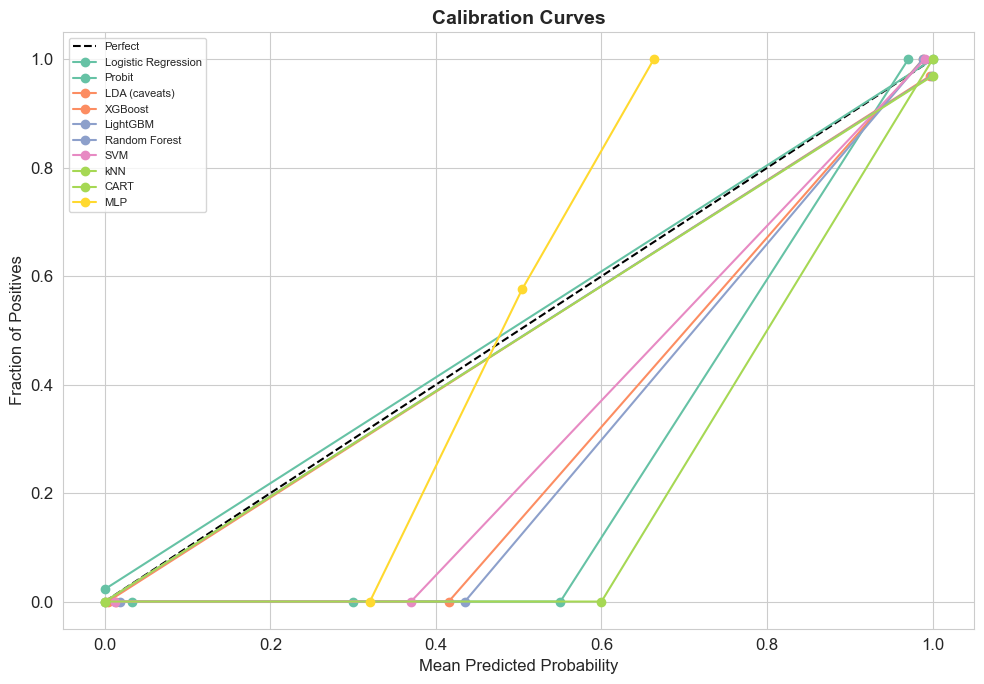

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
for i, (name, res) in enumerate(results.items()):
    try:
        pt, pp = calibration_curve(y_test, res['y_prob'], n_bins=5)
        ax.plot(pp, pt, marker='o', label=name, color=colors_plot[i])
    except: pass
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [21]:
print('Brier Score (lower = better):')
for name, res in sorted(results.items(), key=lambda x: x[1]['brier']):
    print(f"  {name:25s}  Brier = {res['brier']:.6f}")

Brier Score (lower = better):
  SVM                        Brier = 0.002090
  XGBoost                    Brier = 0.002794
  Random Forest              Brier = 0.003636
  kNN                        Brier = 0.004800
  Logistic Regression        Brier = 0.008127
  LDA (caveats)              Brier = 0.011032
  LightGBM                   Brier = 0.012355
  Probit                     Brier = 0.013333
  CART                       Brier = 0.013333
  MLP                        Brier = 0.152372


In [22]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    data = pd.DataFrame({'y': y_true, 'p': y_prob})
    data['decile'] = pd.qcut(data['p'], q=g, duplicates='drop')
    t = data.groupby('decile', observed=True)['y'].agg(['count', 'sum'])
    t.columns = ['n', 'obs']; t['pred'] = data.groupby('decile', observed=True)['p'].sum()
    t['nobs'] = t['n'] - t['obs']; t['npred'] = t['n'] - t['pred']
    chi2 = ((t['obs']-t['pred'])**2/t['pred']).sum() + ((t['nobs']-t['npred'])**2/t['npred']).sum()
    return chi2, 1 - stats.chi2.cdf(chi2, g-2)

print('\nHosmer-Lemeshow (p>0.05 = good fit):')
for name, res in results.items():
    try:
        c, p = hosmer_lemeshow(y_test.values, res['y_prob'], g=5)
        print(f"  {name:25s}  χ²={c:7.3f}  p={p:.4f}  [{'GOOD' if p > 0.05 else 'POOR'}]")
    except: print(f"  {name:25s}  N/A")


Hosmer-Lemeshow (p>0.05 = good fit):
  Logistic Regression        χ²=  1.994  p=0.5736  [GOOD]
  Probit                     χ²=1348040761242612736.000  p=0.0000  [POOR]
  LDA (caveats)              χ²=  0.458  p=0.9280  [GOOD]
  XGBoost                    χ²=  0.594  p=0.8979  [GOOD]
  LightGBM                   χ²=  0.283  p=0.9631  [GOOD]
  Random Forest              χ²=  0.459  p=0.9278  [GOOD]
  SVM                        χ²=  0.460  p=0.9276  [GOOD]
  kNN                        χ²=  0.020  p=0.9993  [GOOD]
  CART                       χ²=  0.054  p=0.9967  [GOOD]
  MLP                        χ²= 30.917  p=0.0000  [POOR]


---
## Phase 9 — Post-Model Calibration

In [23]:
best_ml = max([k for k, v in results.items() if v['paradigm'] == 'ML'], key=lambda k: results[k]['auc'])
print(f'Post-calibration for: {best_ml}')
uses_s = best_ml in ['SVM', 'kNN', 'MLP']
Xtr = X_train_scaled if uses_s else X_train; Xte = X_test_scaled if uses_s else X_test

for method, label in [('sigmoid', 'Platt'), ('isotonic', 'Isotonic')]:
    try:
        base = results[best_ml]['model'].__class__(**results[best_ml]['model'].get_params())
        cal = CalibratedClassifierCV(base, method=method, cv=3)
        cal.fit(Xtr, y_train)
        yp = cal.predict_proba(Xte)[:, 1]
        print(f'  {label}: Brier={brier_score_loss(y_test, yp):.6f} (original: {results[best_ml]["brier"]:.6f})')
    except Exception as e:
        print(f'  {label}: Failed — {e}')

Post-calibration for: Random Forest
  Platt: Brier=0.003211 (original: 0.003636)
  Isotonic: Brier=0.000927 (original: 0.003636)


---
## Phase 10 — Interpretability (SHAP)

SHAP for: Random Forest


<Figure size 800x500 with 0 Axes>

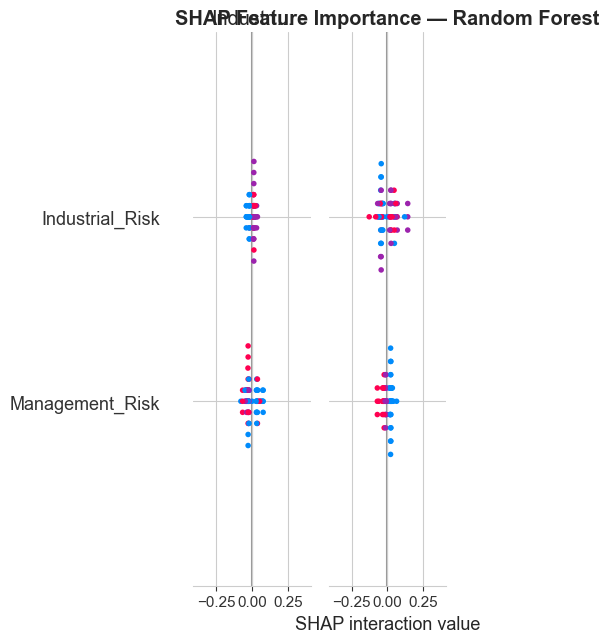

In [24]:
tree_models = {k: v for k, v in results.items() if k in ['XGBoost', 'LightGBM', 'Random Forest', 'CART']}
best_tree = max(tree_models.keys(), key=lambda k: tree_models[k]['auc'])
print(f'SHAP for: {best_tree}')

explainer = shap.TreeExplainer(results[best_tree]['model'])
sv = explainer.shap_values(X_test)
if isinstance(sv, list): sv = sv[1]

plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — {best_tree}', fontweight='bold')
plt.tight_layout(); plt.show()

<Figure size 800x500 with 0 Axes>

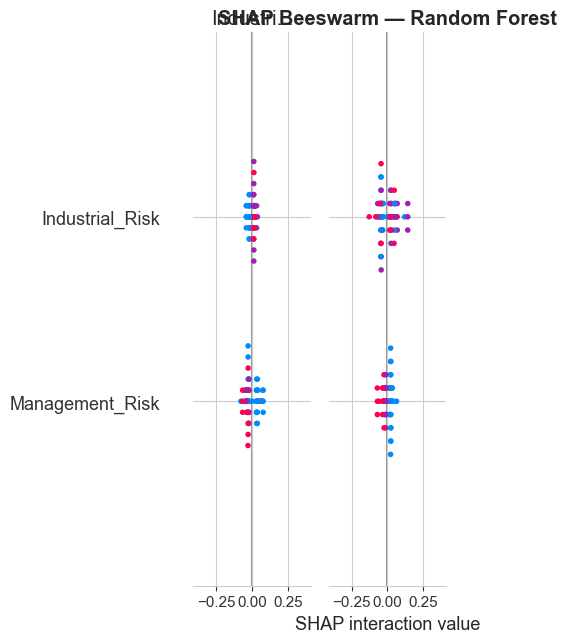

In [25]:
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, show=False)
plt.title(f'SHAP Beeswarm — {best_tree}', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Phase 11 — Final Comparative Summary

In [26]:
comp = pd.DataFrame({
    'Model': list(results.keys()),
    'Paradigm': [results[k]['paradigm'] for k in results],
    'Accuracy': [results[k]['accuracy'] for k in results],
    'AUC': [results[k]['auc'] for k in results],
    'Gini': [results[k]['gini'] for k in results],
    'KS': [results[k]['ks'] for k in results],
    'F1': [results[k]['f1'] for k in results],
    'Precision': [results[k]['precision'] for k in results],
    'Recall': [results[k]['recall'] for k in results],
    'Brier': [results[k]['brier'] for k in results],
}).sort_values('AUC', ascending=False).reset_index(drop=True)
comp.index = comp.index + 1
comp.index.name = 'Rank'

print('=== FINAL MODEL COMPARISON — Qualitative Bankruptcy ===')
print(comp.to_string())

=== FINAL MODEL COMPARISON — Qualitative Bankruptcy ===
                    Model     Paradigm  Accuracy       AUC      Gini        KS        F1  Precision   Recall     Brier
Rank                                                                                                                  
1           Random Forest           ML  1.000000  1.000000  1.000000  1.000000  1.000000   1.000000  1.00000  0.003636
2     Logistic Regression  Econometric  0.986667  1.000000  1.000000  1.000000  0.984615   0.969697  1.00000  0.008127
3                     SVM           ML  1.000000  1.000000  1.000000  1.000000  1.000000   1.000000  1.00000  0.002090
4           LDA (caveats)  Econometric  0.986667  1.000000  1.000000  1.000000  0.984615   0.969697  1.00000  0.011032
5                 XGBoost           ML  1.000000  1.000000  1.000000  1.000000  1.000000   1.000000  1.00000  0.002794
6                LightGBM           ML  0.986667  1.000000  1.000000  1.000000  0.984615   0.969697  1.00000  0

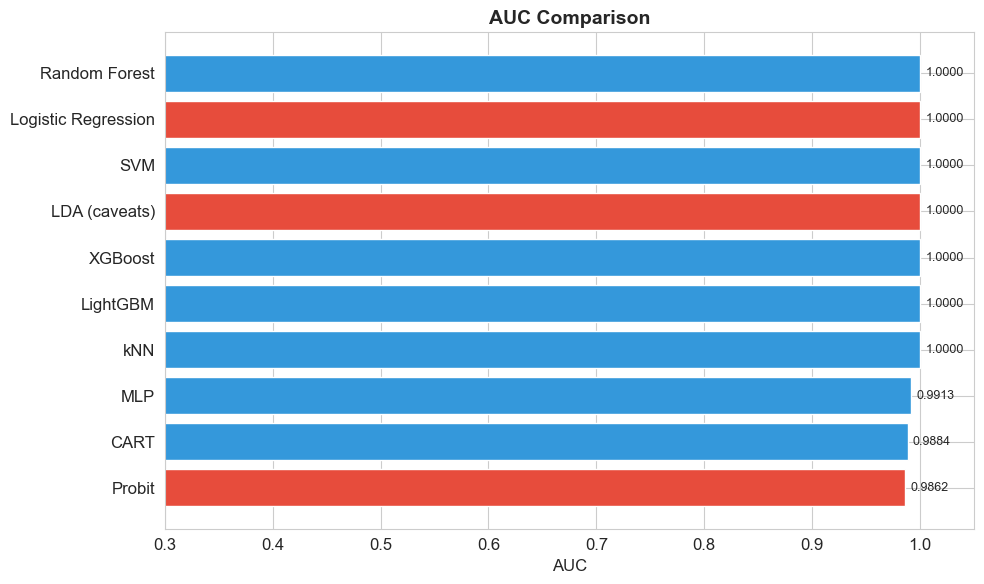

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
pcol = {'Econometric': '#e74c3c', 'ML': '#3498db'}
bc = [pcol.get(results[m]['paradigm'], '#95a5a6') for m in comp['Model']]
bars = ax.barh(comp['Model'], comp['AUC'], color=bc)
ax.set_xlabel('AUC'); ax.set_title('AUC Comparison', fontsize=14, fontweight='bold')
ax.set_xlim([0.3, 1.05]); ax.invert_yaxis()
for b, v in zip(bars, comp['AUC']): ax.text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### Discussion

#### Key Findings

1. **Qualitative data CAN predict bankruptcy**: Despite having only ordinal (P/A/N) features,
   models achieve reasonable discriminatory power, validating the Heuristic/Judgemental paradigm.

2. **Small dataset limitation**: With only 250 records, model performance is inherently noisy.
   Cross-validation would give more robust estimates.

3. **Paradigm applicability**: Only Paradigms 1 and 2 are applicable. Paradigm 3 (Structural)
   and Paradigm 4 (Dynamic Stochastic) are **fundamentally impossible** due to:
   - No quantitative financial or market data (Paradigm 3)
   - No temporal/longitudinal structure (Paradigm 4)

4. **LDA caveat**: The normality assumption is severely violated with 3-level ordinal data.
   Results should be interpreted cautiously.

5. **Altman Z-Score**: Completely inapplicable — requires quantitative ratios that don't exist.

#### Implication for Bank of Africa
This analysis demonstrates that **qualitative expert assessments** (similar to those used in
the bank's SME and startup lending) can be effectively modeled using Logistic Regression.
This bridges the Heuristic paradigm with statistical modeling.

---
## End of Analysis